### Imports

In [1]:
import requests, json, numpy as np, time
from pprint import pprint

### Send ingestion request

In [ ]:
sample = {
    "simulation_id": "E2E_NOTEBOOK",
    "gps": {"lat": 52.371, "lon": 4.893},
    "meteo": {
        "wind_speed": 3.1,
        "wind_dir": 72.4,
        "stability": 4
    },
    "spectrum": list(np.abs(np.random.randn(600)).round(3)),
    "van_status": {
        "battery": 88,
        "temperature": 22.5
    }
}

resp = requests.post("http://localhost:8011/ingest_data", json=sample).json()
pprint(resp)

{'detail': [{'loc': ['body', 'timestamp'],
             'msg': 'field required',
             'type': 'value_error.missing'},
            {'loc': ['body', 'SensorAir'],
             'msg': 'field required',
             'type': 'value_error.missing'},
            {'loc': ['body', 'SensorSubstance'],
             'msg': 'field required',
             'type': 'value_error.missing'},
            {'loc': ['body', 'SensorGPS'],
             'msg': 'field required',
             'type': 'value_error.missing'},
            {'loc': ['body', 'SourceGPS'],
             'msg': 'field required',
             'type': 'value_error.missing'}]}


### Load last bundle

In [3]:
bundles = requests.get("http://localhost:8013/forensic_bundles").json()["bundles"]
bundle = requests.get(f"http://localhost:8013/forensic_bundle/{bundles[0]}").json()
event = bundle["bundle"]["event"]
pprint(event)

{'ForensicExport': {'compliance_tags': ['DRIFT_OK',
                                        'LATENCY_OK',
                                        'GDPR_SIMULATION_ONLY',
                                        'SIGNATURE_OK',
                                        'HASH_OK',
                                        'ARTIFACTS_OK'],
                    'export_file': 'E2E_TEST_bundle.zip'},
 'Inference': {'confidence_score': 0.9656981825828552,
               'dispersion_map_id': 'e0f89b51c45bfb10bf30582e8c11eafbead978e8781d76a37ee2620fab1d9206',
               'predicted_class': 'Other compounds',
               'predicted_source_location': [86.075892968143,
                                             114.68156138999885]},
 'ModelOps': {'model_registry_id': 'mdl_pention_m',
              'retraining_trigger': False,
              'training_data_version': 'PIML_DS_PIML_v1'},
 'Monitoring': {'drift_score': 0.0,
                'latency_ms': 11.24,
                'model_version': 'PIML_

### Plot stability & drift

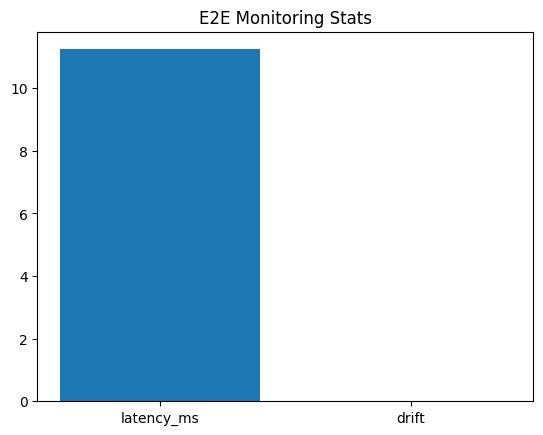

In [ ]:
import matplotlib.pyplot as plt

lat = event["Monitoring"]["latency_ms"]
drift = event["Monitoring"]["drift_score"]
plt.bar(["latency_ms","drift"], [lat, drift])
plt.title("E2E Monitoring Stats")
plt.show()

### Validate

In [5]:
assert event["Monitoring"]["latency_ms"] < 500
assert event["Monitoring"]["drift_score"] < 0.6
assert len(event["SensorSubstance"]["spectrum_ei_1_600"]) == 600

print("OK")

OK
